<a href="https://colab.research.google.com/github/Vicodwer/Day_30/blob/main/Day_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Part A — Concept Application

1. Data Loading & Exploration

In [12]:
df = pd.read_csv("/content/suv_data.csv")

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510.0,Male,19.0,19000.0,0.0
1,15810944.0,Male,35.0,20000.0,0.0
2,15668575.0,Female,26.0,43000.0,0.0
3,15603246.0,Female,27.0,57000.0,0.0
4,15804002.0,Male,19.0,76000.0,0.0


In [13]:
df.shape

(400, 5)

In [14]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [15]:
df.dtypes

,0
User ID,float64
Gender,object
Age,float64
EstimatedSalary,float64
Purchased,float64


In [6]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


2. Data Preprocessing



In [16]:
df = df.dropna()

In [18]:
# Encode categorical variable (Gender)
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [19]:
# Select relevant features
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [20]:
print("\nFeatures (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)


Features (X) Shape: (400, 2)
Target (y) Shape: (400,)


3. Train-Test Split (80/20)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTraining Size:", X_train.shape)
print("Testing Size:", X_test.shape)


Training Size: (320, 2)
Testing Size: (80, 2)


4. Feature Scaling

In [23]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model Training

In [24]:
model = LogisticRegression()
# Fit model
model.fit(X_train, y_train)
print("\nModel Training Completed")


Model Training Completed


# Part B — Stretch Problem

1. Model Evaluation

In [25]:
y_pred = model.predict(X_test)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


Accuracy: 0.8625


In [27]:
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[50  2]
 [ 9 19]]


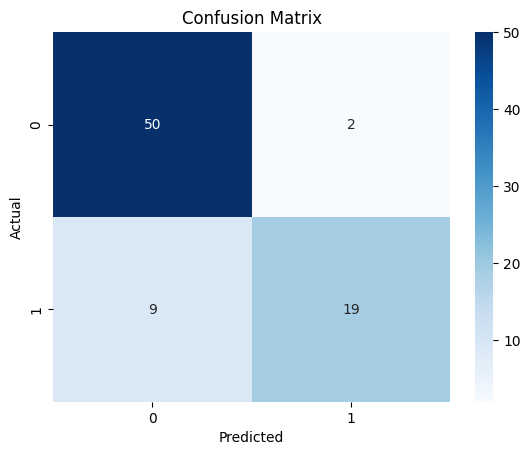

In [28]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

2. Decision Boundary Visualization

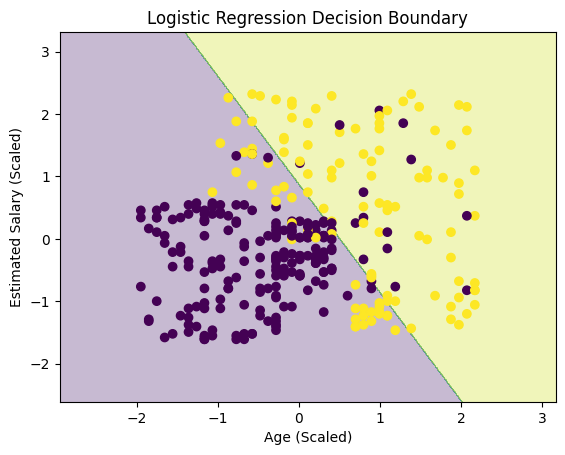

In [29]:
X_set, y_set = X_train, y_train.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(X1, X2, model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.3)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set)
plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Age (Scaled)")
plt.ylabel("Estimated Salary (Scaled)")
plt.show()

Clear separation between buyers (1) and non-buyers (0)
Logistic Regression creates a linear decision boundary
Works well when classes are linearly separable

3. Try Different Test Sizes

In [30]:
for size in [0.3, 0.25]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=size, random_state=42
    )

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\nTest Size {size} Accuracy:", acc)


Test Size 0.3 Accuracy: 0.85

Test Size 0.25 Accuracy: 0.86


# Part C — Interview Ready

Q1 — What is Logistic Regression

Answer:

Logistic Regression is a Supervised Machine Learning Classification algorithm
It predicts probability using Sigmoid function

Output range = 0 to 1
Used for Binary Classification

Formula:

𝑃(𝑦=1)
=
1
1
+
𝑒
−
(
𝑏
0
+
𝑏
1
𝑥
1
+
𝑏
2
𝑥
2
)
P(y=1)=
1+e
−(b0+b1x1+b2x2)
1
	​


It is called "Regression" because it estimates probabilities using regression equation, but it is used for classification.

Q2 — Code for Train-Test Split & Scaling

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Q3 — What is Confusion Matrix?

A confusion matrix is a 2×2 table for classification:

	Predicted 0	Predicted 1
Actual  0	 TN	 FP

Actual  1	 FN  TP

TP → Correctly predicted buyers
TN → Correctly predicted non-buyers
FP → Wrongly predicted buyer
FN → Missed actual buyer

It helps calculate:

Accuracy

Precision

Recall

F1 Score

# Part D — AI-Augmented Task

🔹 Prompt Given to AI:

"Explain Logistic Regression with Python example using sklearn on SUV dataset."

🔹 AI Output (Example)

Logistic Regression is used for binary classification. It predicts probabilities using sigmoid function.

Example code:


In [32]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()